# Transfer Learning v2 — Improved

Same three pretrained backbones as v1, with targeted improvements:

| # | Change | Reason |
|---|---|---|
| 1 | **224×224 input** (vs 128×128) | Matches ImageNet training resolution; helps small/thin classes (pen, keychain). |
| 2 | **Asymmetric Loss** (ASL) | Down-weights easy negatives; much better for multi-label with many absent classes. |
| 3 | **Stratified split** by label combo | Preserves rare-class representation in val/test splits. |
| 4 | **RandAugment + RandomErasing** | Stronger, principled augmentation policy. |
| 5 | **Per-class threshold tuning** on val | Each class gets its own optimal threshold rather than a shared 0.5. |
| 6 | **Two-stage full fine-tune + discriminative LRs** | Freeze backbone for warmup epochs, then unfreeze **everything** with head LR 10× backbone LR. Partial freezing (only last block) was the main bottleneck at F1≈0.70. |

## 1. Imports & Setup

In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from collections import defaultdict
from torchvision import models as tv_models
from torchvision import transforms
from torchvision.transforms import RandAugment, RandomErasing
from torch.utils.data import DataLoader, Subset

sys.path.append("../")
from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset,
    plot_per_class_examples, plot_multilabel_examples,
    run_baselines, print_model_info,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, plot_multi_arch_histories,
    collect_test_predictions, categorize_predictions,
    show_prediction_examples, plot_per_class_metrics,
    plot_confusion_matrices, plot_prediction_heatmap,
    show_saliency_examples, compute_multilabel_metrics,
    NUM_LABELS, METRIC_KEYS, NORM_MEAN, NORM_STD, TransformSubset,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Config

In [2]:
BASE_DATA_DIR   = "../data/aggregated"
IMAGE_SIZE      = 224          # up from 128 — matches ImageNet backbone input
BATCH_SIZE      = 32           # reduced from 128 to fit larger images in memory
SPLIT           = [0.7, 0.15, 0.15]

USE_SUBSET      = False
SUBSET_FRACTION = 0.1

CHECKPOINT_DIR  = Path("../checkpoints")

print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")

Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


## 3. Asymmetric Loss

Standard BCE treats all negatives equally. In multi-label with 12 classes, most labels
are absent for any image — those easy negatives dominate and dilute the useful gradient.
ASL decouples the focal parameter for positives (`gamma_pos`) and negatives (`gamma_neg`),
and shifts negative probabilities by a small margin `clip` to further suppress easy negatives.

In [3]:
class AsymmetricLoss(nn.Module):
    """Asymmetric Loss for multi-label classification (Ben-Baruch et al. 2020)."""

    def __init__(self, gamma_neg: float = 4, gamma_pos: float = 1,
                 clip: float = 0.05, eps: float = 1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs_pos = torch.sigmoid(logits)
        probs_neg = 1 - probs_pos
        if self.clip > 0:
            probs_neg = (probs_neg + self.clip).clamp(max=1.0)
        loss_pos = targets       * torch.log(probs_pos.clamp(min=self.eps))
        loss_neg = (1 - targets) * torch.log(probs_neg.clamp(min=self.eps))
        loss = loss_pos + loss_neg
        pt    = probs_pos * targets + probs_neg * (1 - targets)
        gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
        loss  = loss * (1 - pt).pow(gamma)
        return -loss.mean()

## 4. Data Loading — Stratified Split + RandAugment

Random split can put all images of a rare label combination into train, starving val/test.
Stratified split by label combination distributes every combo proportionally.

In [4]:
def stratified_split_multilabel(dataset, split, seed=42):
    """
    Stratified split for multi-label data.
    Groups samples by their label combination and distributes each group
    proportionally across train / val / test.
    """
    combo_to_indices = defaultdict(list)
    for i in range(len(dataset)):
        _, target = dataset[i]
        combo = tuple(target.int().tolist())
        combo_to_indices[combo].append(i)

    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for indices in combo_to_indices.values():
        indices = np.array(indices)
        rng.shuffle(indices)
        n       = len(indices)
        n_val   = max(1 if n >= 3 else 0, round(split[1] * n))
        n_test  = max(1 if n >= 3 else 0, round(split[2] * n))
        n_train = max(0, n - n_val - n_test)
        train_idx.extend(indices[:n_train].tolist())
        val_idx.extend(indices[n_train : n_train + n_val].tolist())
        test_idx.extend(indices[n_train + n_val :].tolist())

    return (
        Subset(dataset, train_idx),
        Subset(dataset, val_idx),
        Subset(dataset, test_idx),
    )

In [5]:
# RandAugment replaces the hand-crafted jitter/affine stack.
# RandomErasing forces the network off a single discriminative patch —
# especially useful when multiple objects can occlude each other.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
    RandomErasing(p=0.25, scale=(0.02, 0.1), value=0.0),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

full_dataset = load_dataset(BASE_DATA_DIR)
train_raw, val_raw, test_raw = stratified_split_multilabel(full_dataset, SPLIT, SEED)

if USE_SUBSET:
    from utils import subsample_subset
    train_raw = subsample_subset(train_raw, SUBSET_FRACTION, SEED)
    val_raw   = subsample_subset(val_raw,   SUBSET_FRACTION, SEED + 1)
    test_raw  = subsample_subset(test_raw,  SUBSET_FRACTION, SEED + 2)

train_ds = TransformSubset(train_raw, transform=train_transform)
val_ds   = TransformSubset(val_raw,   transform=eval_transform)
test_ds  = TransformSubset(test_raw,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Total: {len(full_dataset)}  |  "
      f"Train: {len(train_raw)}  Val: {len(val_raw)}  Test: {len(test_raw)}")

Total: 4543  |  Train: 3205  Val: 669  Test: 669


## 5. Visualize Train Samples

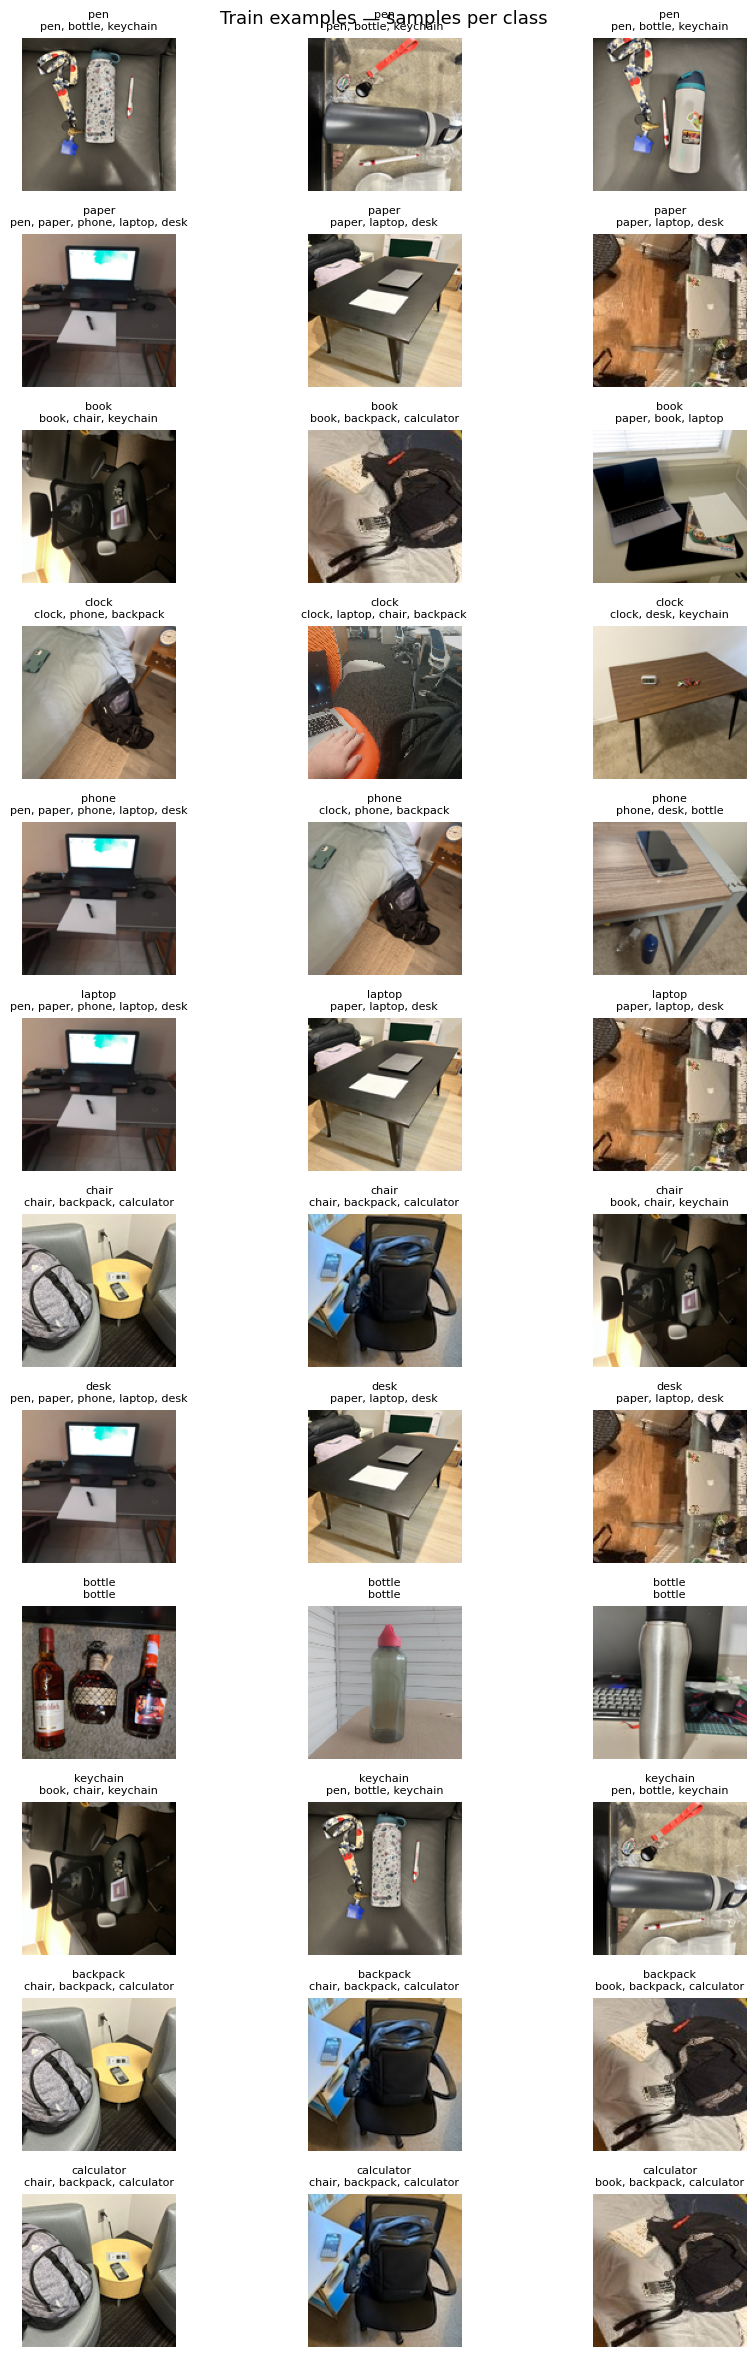

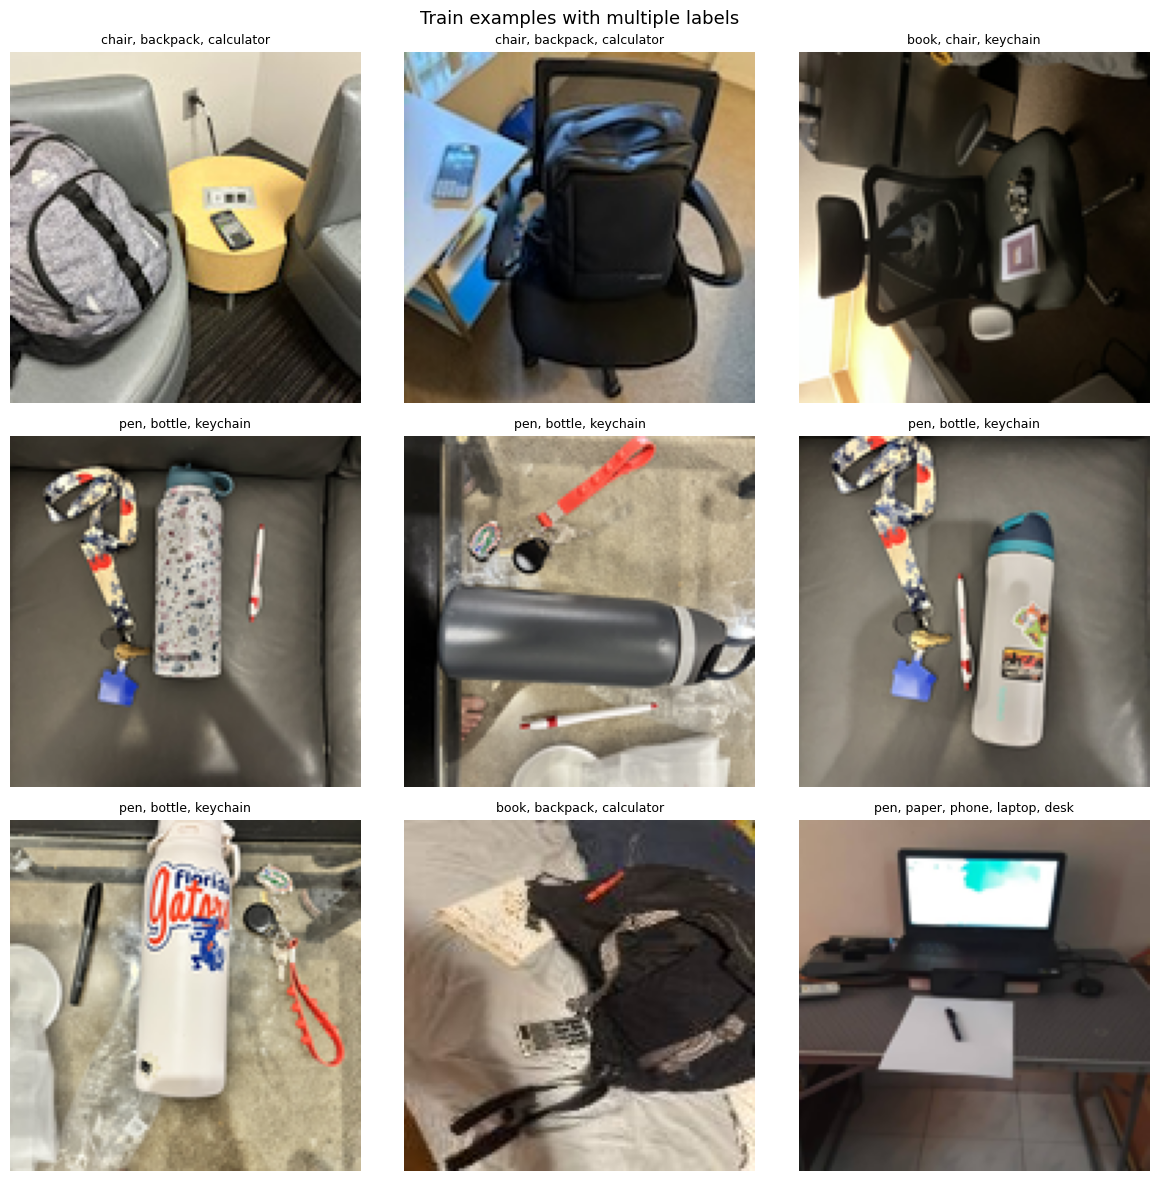

In [6]:
plot_per_class_examples(train_raw)
plot_multilabel_examples(train_raw)

## 6. Baselines

In [7]:
run_baselines(train_loader, val_loader, test_loader, NUM_LABELS, DEVICE)

Train label prevalence (sorted):
  #1  pen           0.169
  #2  laptop        0.162
  #3  bottle        0.162
  #4  paper         0.159
  #5  book          0.159
  #6  phone         0.158
  #7  calculator    0.144
  #8  keychain      0.140
  #9  chair         0.138
  #10 backpack      0.135
  #11 desk          0.132
  #12 clock         0.113

=== top-1 freq  (Val) ===
  loss             0.5441
  exact_match      0.0344
  hamming_acc      0.8003
  mean_iou         0.0894
  precision_micro  0.1659
  recall_micro     0.0960
  f1_micro         0.1216

=== top-2 freq  (Val) ===
  loss             0.6703
  exact_match      0.0030
  hamming_acc      0.7429
  mean_iou         0.1135
  precision_micro  0.1607
  recall_micro     0.1860
  f1_micro         0.1724

=== top-3 freq  (Val) ===
  loss             0.7943
  exact_match      0.0015
  hamming_acc      0.6865
  mean_iou         0.1278
  precision_micro  0.1609
  recall_micro     0.2794
  f1_micro         0.2042

=== random  (Val) ===
  los

('random',
 {'loss': 0.6934470534324646,
  'exact_match': 0.0,
  'hamming_acc': 0.49775785207748413,
  'mean_iou': 0.12677808105945587,
  'precision_micro': 0.14157527685165405,
  'recall_micro': 0.4913494884967804,
  'f1_micro': 0.2198142409324646},
 {'loss': 0.6935147047042847,
  'exact_match': 0.0014947683084756136,
  'hamming_acc': 0.5017439126968384,
  'mean_iou': 0.12850035727024078,
  'precision_micro': 0.14271356165409088,
  'recall_micro': 0.4913494884967804,
  'f1_micro': 0.22118380665779114})

## 7. Model — Transfer Learning Architectures

Each backbone is wrapped in `TransferModel` which exposes:
- `backbone` — pretrained feature extractor
- `head` — randomly-initialised classification head
- `set_backbone_trainable(flag)` — toggle all backbone params

**Two-stage strategy:**
1. **Warmup** (`FREEZE_EPOCHS`): backbone fully frozen, only head trains. Prevents random-init head gradients from scrambling ImageNet features.
2. **Full fine-tune** (`UNFREEZE_EPOCHS`): backbone unfrozen with a 10× smaller LR than the head (discriminative LRs).

In [ ]:
import torch.optim as optim
import copy
import time

class TransferModel(nn.Module):
    """
    Thin wrapper around a pretrained torchvision backbone that:
    - normalises access to backbone / head for any architecture
    - exposes set_backbone_trainable() for two-stage fine-tuning
    """
    def __init__(self, backbone: nn.Module, head: nn.Module):
        super().__init__()
        self.backbone = backbone
        self.head     = head

    def forward(self, x):
        return self.head(self.backbone(x))

    def set_backbone_trainable(self, flag: bool):
        for p in self.backbone.parameters():
            p.requires_grad = flag


def build_transfer_model(arch: str, num_labels: int) -> TransferModel:
    if arch == "resnet18":
        m        = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(m.children())[:-1], nn.Flatten())  # up to avgpool
        head     = nn.Linear(512, num_labels)

    elif arch == "efficientnet_b0":
        m        = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(m.features, m.avgpool, nn.Flatten())
        head     = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, num_labels))

    elif arch == "mobilenet_v2":
        m        = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten())
        head     = nn.Sequential(nn.Dropout(0.2), nn.Linear(1280, num_labels))

    else:
        raise ValueError(f"Unknown arch: {arch}")

    model = TransferModel(backbone, head)
    # Initialise new head
    for layer in (model.head.modules() if hasattr(model.head, 'modules') else [model.head]):
        if isinstance(layer, nn.Linear):
            nn.init.normal_(layer.weight, 0, 0.01)
            nn.init.zeros_(layer.bias)
    return model


ARCHS = ["resnet18", "efficientnet_b0", "mobilenet_v2"]

print(f"{'Arch':<22} {'Total':>10}  {'Size':>9}")
print("-" * 48)
for arch in ARCHS:
    m     = build_transfer_model(arch, NUM_LABELS)
    total = sum(p.numel() for p in m.parameters())
    size_mb = total * 4 / 1024 / 1024
    print(f"{arch:<22} {total:>10,}  {size_mb:.2f} MB")

Arch                    Trainable      Total   Ratio       Size
-----------------------------------------------------------------
resnet18                8,399,884 11,182,668   75.1%   42.66 MB
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/abbasidaniyal/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


efficientnet_b0           427,532  4,022,920   10.6%   15.35 MB
mobilenet_v2              901,452  2,239,244   40.3%    8.54 MB


## 8. Training — Two-Stage Fine-Tune with Discriminative LRs

In [ ]:
criterion      = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
FREEZE_EPOCHS  = 3        # head-only warmup
UNFREEZE_EPOCHS = 15      # full fine-tune after warmup
MAX_EPOCHS     = FREEZE_EPOCHS + UNFREEZE_EPOCHS
LR_HEAD        = 1e-3
LR_BACKBONE    = 1e-4     # 10× smaller — protects ImageNet features
WEIGHT_DECAY   = 1e-4
GRAD_CLIP      = 1.0
THRESHOLD      = 0.5


def run_epoch(model, loader, optimizer=None, train=True):
    model.train(train)
    all_logits, all_probs, all_preds, all_labels = [], [], [], []
    total_loss = 0.0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = model(images)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], GRAD_CLIP
                )
                optimizer.step()
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= THRESHOLD).float()
        total_loss  += loss.item() * images.size(0)
        all_logits.append(logits.detach().cpu())
        all_probs.append(probs.detach().cpu())
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.cpu())

    n = sum(l.size(0) for l in all_labels)
    metrics = compute_multilabel_metrics(
        torch.cat(all_labels), torch.cat(all_preds),
        probs=torch.cat(all_probs), logits=torch.cat(all_logits),
    )
    metrics["loss"] = total_loss / n
    return metrics


def train_two_stage(arch):
    model = build_transfer_model(arch, NUM_LABELS).to(DEVICE)

    # Stage A: freeze backbone, train head only
    model.set_backbone_trainable(False)
    optimizer = optim.AdamW(
        [{"params": list(model.head.parameters()), "lr": LR_HEAD}],
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    best_val_f1 = -1.0
    best_state  = None
    history     = {"train": {k: [] for k in METRIC_KEYS},
                   "val":   {k: [] for k in METRIC_KEYS}}

    print(f"[Stage A] backbone frozen for {FREEZE_EPOCHS} epochs")
    for epoch in range(1, MAX_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            # Stage B: unfreeze backbone with discriminative LR
            model.set_backbone_trainable(True)
            optimizer = optim.AdamW(
                [
                    {"params": list(model.head.parameters()),     "lr": LR_HEAD},
                    {"params": list(model.backbone.parameters()), "lr": LR_BACKBONE},
                ],
                weight_decay=WEIGHT_DECAY,
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=UNFREEZE_EPOCHS
            )
            print(f"[Stage B] backbone unfrozen — full fine-tune for {UNFREEZE_EPOCHS} epochs")

        t0           = time.time()
        train_m      = run_epoch(model, train_loader, optimizer, train=True)
        val_m        = run_epoch(model, val_loader,   train=False)
        scheduler.step()

        for k in METRIC_KEYS:
            history["train"][k].append(train_m[k])
            history["val"][k].append(val_m[k])

        stage = "A" if epoch <= FREEZE_EPOCHS else "B"
        print(f"[{stage}] Epoch {epoch:02d}/{MAX_EPOCHS} | {time.time()-t0:4.1f}s | "
              f"train f1={train_m['f1_micro']:.4f} loss={train_m['loss']:.4f} | "
              f"val f1={val_m['f1_micro']:.4f} loss={val_m['loss']:.4f}")

        if val_m["f1_micro"] > best_val_f1:
            best_val_f1 = val_m["f1_micro"]
            best_state  = copy.deepcopy(model.state_dict())
            print(f"       -> new best val F1={best_val_f1:.4f}")

    model.load_state_dict(best_state)
    model.eval()
    return model, best_val_f1, history


all_histories = {}
best_models   = {}
best_val_f1s  = {}

for arch in ARCHS:
    print(f"\n{'='*60}\n  {arch}\n{'='*60}")
    m, best_f1, history = train_two_stage(arch)
    ckpt = CHECKPOINT_DIR / f"tl_v2_{arch}.pth"
    save_checkpoint(m.state_dict(), ckpt)
    all_histories[arch] = {k: {"train": history["train"][k], "val": history["val"][k]}
                           for k in METRIC_KEYS}
    best_models[arch]   = m
    best_val_f1s[arch]  = best_f1
    print(f"  Best val F1: {best_f1:.4f}")

print("\n\n=== Val F1 Summary ===")
for arch in ARCHS:
    print(f"  {arch:<22} {best_val_f1s[arch]:.4f}")


  resnet18

Epoch  1/20  [lr=3.33e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4922    0.4350
  exact_match            0.1217    0.1973
  hamming_acc            0.8025    0.8514
  mean_iou               0.4382    0.5404
  precision_micro        0.4090    0.4908
  recall_micro           0.7607    0.8581
  f1_micro               0.5320    0.6245

Epoch  2/20  [lr=6.67e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4455    0.3968
  exact_match            0.1800    0.2885
  hamming_acc            0.8493    0.8888
  mean_iou               0.5182    0.6063
  precision_micro        0.4935    0.5788
  recall_micro           0.8107    0.8356
  f1_micro               0.6135    0.6839

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4387    0.4144
  exact_match      

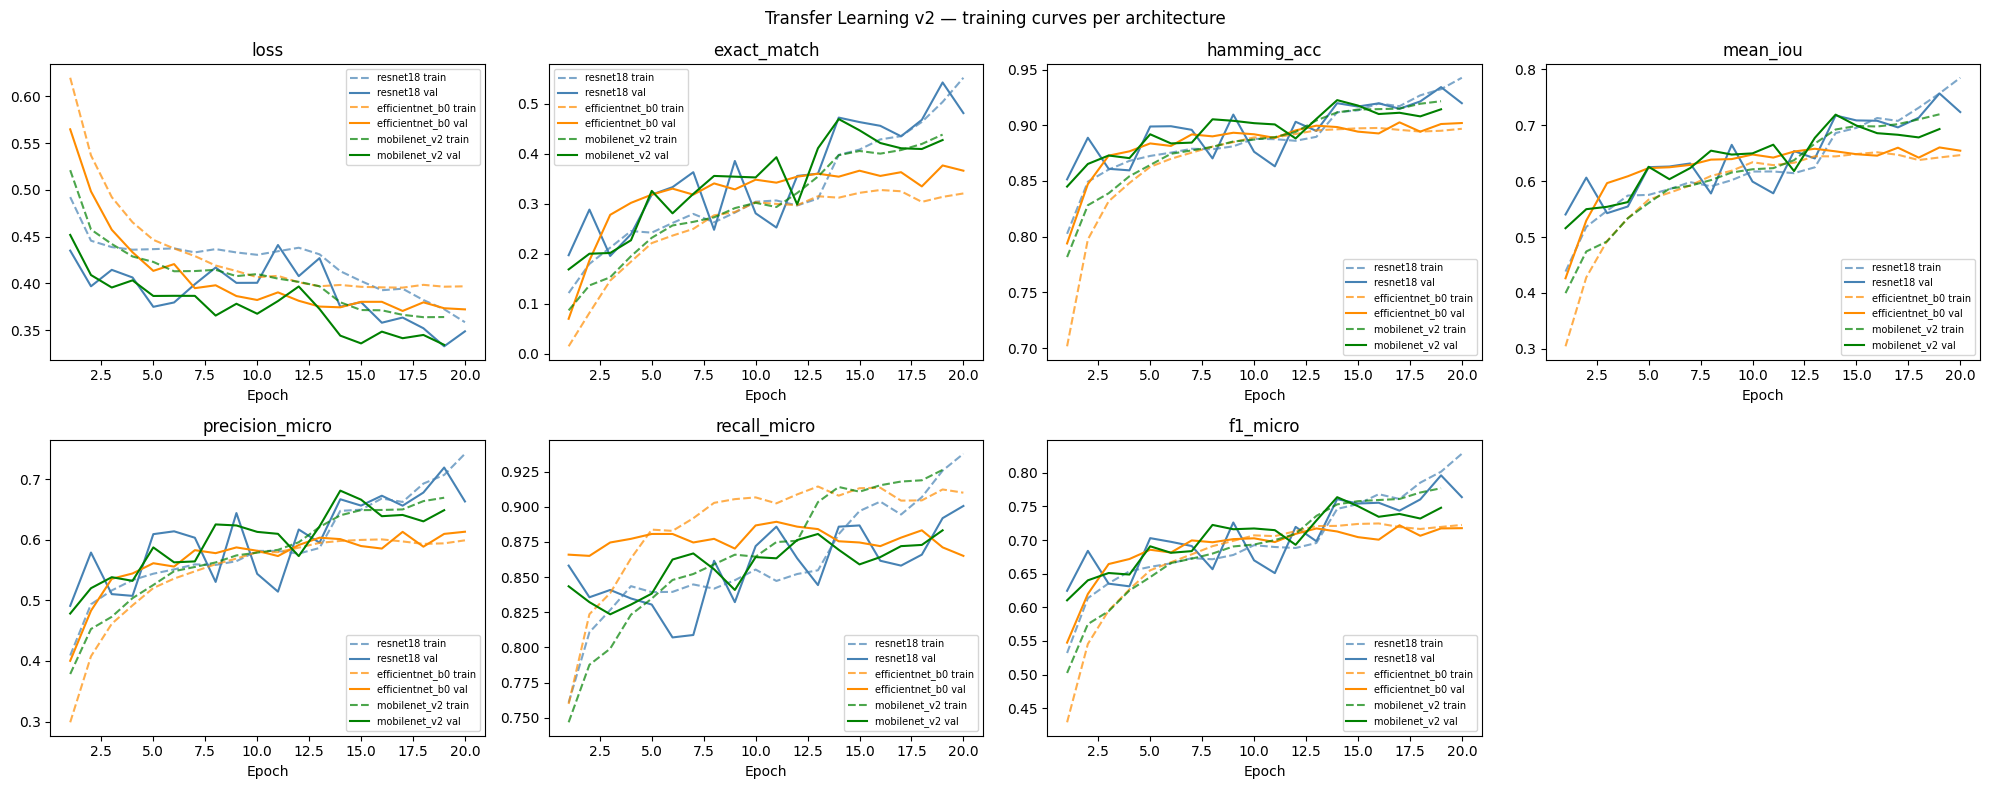

In [10]:
plot_multi_arch_histories(all_histories, experiment_name="Transfer Learning v2")

## 9. Per-Class Threshold Tuning

A single threshold of 0.5 is sub-optimal when class prevalences differ. We grid-search
each class's threshold independently on the **val set only**, then apply the tuned
thresholds to the **test set** to get an honest performance estimate.

In [ ]:
THRESHOLD_GRID = np.arange(0.05, 0.96, 0.02)


def tune_per_class_thresholds(model, val_loader, device, grid):
    """Grid-search per-class threshold that maximises F1 on val set."""
    all_probs, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            probs = torch.sigmoid(model(images.to(device)))
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    probs  = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    thresholds = []
    for c in range(labels.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            preds = (probs[:, c] >= t).float()
            tp = ((preds == 1) & (labels[:, c] == 1)).sum().float()
            fp = ((preds == 1) & (labels[:, c] == 0)).sum().float()
            fn = ((preds == 0) & (labels[:, c] == 1)).sum().float()
            f1 = (2 * tp / (2 * tp + fp + fn + 1e-8)).item()
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds.append(float(best_t))
    return thresholds, probs, labels


print("Tuning per-class thresholds on val set...\n")
per_class_thresholds = {}
val_probs_all        = {}
val_labels_cached    = None

for arch, m_eval in best_models.items():
    thresholds, val_probs, val_labels = tune_per_class_thresholds(
        m_eval, val_loader, DEVICE, THRESHOLD_GRID
    )
    per_class_thresholds[arch] = thresholds
    val_probs_all[arch]        = val_probs
    val_labels_cached          = val_labels

    thr_tensor = torch.tensor(thresholds).unsqueeze(0)
    val_preds  = (val_probs >= thr_tensor).float()
    m          = compute_multilabel_metrics(val_labels, val_preds, probs=val_probs)
    print(f"{arch}  — val F1 with per-class thresholds: {m['f1_micro']:.4f}")
    for i, cls in enumerate(LABEL_ORDER):
        print(f"  {cls:<12}  thr={thresholds[i]:.2f}")
    print()

## 10. Test Evaluation

Reports default threshold (0.5) and val-tuned per-class thresholds side-by-side.

In [ ]:
print(f"\n{'Arch':<22} {'loss':>7} {'exact':>7} {'hamming':>7} "
      f"{'IoU':>7} {'prec':>7} {'rec':>7} {'F1@0.5':>8} {'F1@tuned':>10}")
print("-" * 100)

for arch, m_eval in best_models.items():
    thr_tensor = torch.tensor(per_class_thresholds[arch]).unsqueeze(0)
    all_l, all_p_def, all_p_tuned, all_pr, all_lg = [], [], [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = m_eval(images)
            probs  = torch.sigmoid(logits)
            all_l.append(labels.cpu())
            all_p_def.append((probs >= 0.5).float().cpu())
            all_p_tuned.append((probs.cpu() >= thr_tensor).float())
            all_pr.append(probs.cpu())
            all_lg.append(logits.cpu())

    labels_t = torch.cat(all_l)
    probs_t  = torch.cat(all_pr)
    logits_t = torch.cat(all_lg)
    m_def    = compute_multilabel_metrics(labels_t, torch.cat(all_p_def),
                                          probs=probs_t, logits=logits_t)
    m_tuned  = compute_multilabel_metrics(labels_t, torch.cat(all_p_tuned),
                                          probs=probs_t, logits=logits_t)
    print(f"{arch:<22} {m_def['loss']:>7.4f} {m_def['exact_match']:>7.4f} "
          f"{m_def['hamming_acc']:>7.4f} {m_def['mean_iou']:>7.4f} "
          f"{m_def['precision_micro']:>7.4f} {m_def['recall_micro']:>7.4f} "
          f"{m_def['f1_micro']:>8.4f} {m_tuned['f1_micro']:>10.4f}")

## 11. Analyze Predictions (Best Architecture)

In [ ]:
BEST_ARCH    = max(best_val_f1s, key=best_val_f1s.get)
model        = best_models[BEST_ARCH]
MODEL_PATH   = CHECKPOINT_DIR / f"tl_v2_{BEST_ARCH}.pth"
create_model = lambda nl: build_transfer_model(BEST_ARCH, nl)
thr_tensor   = torch.tensor(per_class_thresholds[BEST_ARCH]).unsqueeze(0)

print(f"Best arch: {BEST_ARCH}  (val F1={best_val_f1s[BEST_ARCH]:.4f})")

In [ ]:
# collect_test_predictions uses threshold=0.5 internally;
# we override preds with the tuned per-class thresholds below.
images_t, labels_t, _, probs_t = collect_test_predictions(model, test_loader, DEVICE)
preds_t = (probs_t >= thr_tensor).float()

correct_idx, partial_idx, incorrect_idx = categorize_predictions(labels_t, preds_t)

show_prediction_examples(correct_idx,   images_t, labels_t, preds_t, "Fully Correct",     n=4)
show_prediction_examples(partial_idx,   images_t, labels_t, preds_t, "Partially Correct", n=4)
show_prediction_examples(incorrect_idx, images_t, labels_t, preds_t, "Fully Incorrect",   n=4)

In [ ]:
plot_per_class_metrics(labels_t, preds_t)
plot_confusion_matrices(labels_t, preds_t)
plot_prediction_heatmap(labels_t, preds_t)

## 12. Saliency Maps (Best Architecture)

In [ ]:
show_saliency_examples(correct_idx,   images_t, labels_t, preds_t, model, "Fully Correct",     n=5, device=DEVICE)
show_saliency_examples(partial_idx,   images_t, labels_t, preds_t, model, "Partially Correct", n=5, device=DEVICE)
show_saliency_examples(incorrect_idx, images_t, labels_t, preds_t, model, "Fully Incorrect",   n=5, device=DEVICE)